# Simulation Identity

In [ ]:
%load_ext autoreload
%autoreload 2

from qcheom import *
plt.style.use('qcheom-default')

import numpy as np 
import qutip as q
import matplotlib.pyplot as plt
import pandas as pd
import time

red, blue, orange, grey = '#B74244', '#459DD9', '#ED8532', '#A9ACBC'

## local

In [ ]:
import numpy as np
from qiskit import QuantumCircuit
from qcheom import calcTimeEvo

# Manual idle time corresponding to 10 ns.
# This is used here to construct repeated 2pi rotations explicitly.
# Usually, users should set kwargs["idlingTime"]
idling_manual = int(10 / (1e-3 * 0.1))

# Qiskit quantum circuit
qc = QuantumCircuit(1)
for _ in range(3):
    qc.rx(np.pi, 0)
    qc.delay(0, 0)
    qc.rx(np.pi, 0)
    qc.delay(idling_manual, 0)

kwargs = {
    "numQ": 1,
    "freqQ": [5],  # GHz
    "rhoIni": [
        [1, 0],
        [0, 0],
    ],
    "gateTime": [16],  # ns
    "idlingTime": 0,  # ns
    "T": 30,  # mK
    "T1": 10,  # us
    "omegaC": 20,
    "exp": 1,
    "tol": 1e-6,
    "dtFB": 0.1,  # ps
    "depth": [1],
    "bondDim": 5,
    "strideTime": 0.1,  # ns
    "useRFPlus": False,
    "isRK13": False,
}

kwargs["directory"] = "development/results/local/sim_Id"
kwargs["fileName"] = "Id_s1"
kwargs["qc"] = qc

# expected runtime
calcTimeEvo(**kwargs)

## HPC

In [5]:
import numpy as np
from qiskit import QuantumCircuit

# Manual idle time corresponding to 10 ns.
# This is used here to construct repeated 2pi rotations explicitly.
# Usually, users should set kwargs["idlingTime"]
idling_manual = int(10 / (1e-3 * 0.1))

# Qiskit quantum circuit
qc = QuantumCircuit(1)
for _ in range(3):
    qc.rx(np.pi, 0)
    qc.delay(0, 0)
    qc.rx(np.pi, 0)
    qc.delay(idling_manual, 0)

kwargs = {
    "numQ": 1,
    "freqQ": [5],  # GHz
    "rhoIni": [
        [1, 0],
        [0, 0],
    ],
    "gateTime": [16],  # ns
    "idlingTime": 0,  # ns
    "T": 30,  # mK
    "T1": 10,  # us
    "omegaC": 20,
    "exp": 1,
    "tol": 1e-6,
    "dtFB": 0.1,  # ps
    "depth": [1],
    "bondDim": 5,
    "strideTime": 0.1,  # ns
    "useRFPlus": False,
    "isRK13": False,
}

kwargs["directory"] = "development/results/hpc/sim_Id"
kwargs["fileName"] = "Id_s1"
kwargs["qc"] = qc

In [ ]:
submissionParams = {
    "hostname":      "cluster.example.org",
    "username":      "myusername",
    "password":      "mypassword",
    "schedulerName": "slurm",
    "numNodes":      1,
    "cpusPerTask":   1,
    "maxTime":       "336:00:00",
    "venvPath":      '$HOME/python_HEOM/.venv',
    "emailAddress":  "user@example.org",
    "others":        "",
}

calcTimeEvoHPC(submissionParams, **kwargs)

In [ ]:
# download result

directory = "development/results/hpc/sim_Id"
fileName = "Id_s1"
csvFilePath = os.path.join(os.getcwd(), directory, fileName + '.csv')

jobID = "myjobid"

downloadParams = {
    "hostname":      "cluster.example.org",
    "username":      "myusername",
    "password":      "mypassword",
    "schedulerName": "slurm",
}
import getpass
downloadParams['otp'] = getpass.getpass('Your OTP: ')

downloadResult(downloadParams, jobID, csvFilePath)

## reload

{'directory': 'development/results/paper/sim_Id', 'fileName': 'Id_s1', 'numQ': 1, 'freqQ': [5.0], 'gateTime': [16.0], 'T': array([30.]), 'T1': array([10.]), 'omegaC': [20], 'exp': [1], 'tol': [1e-05], 'idlingTime': 0.0, 'dtFB': 0.2, 'depth': [1], 'bondDim': 5, 'strideTime': 0.10000000000000002, 'useRFPlus': False, 'isRK13': False, 'rhoIni': array([[1.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j]]), 'qc': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000222B1B6CD90>}
------------
{'idlingTime': 0.0, 'gateList': [[[0], 'rxyStep', {'omega': -1.0, 'gateTime': 502.6548245743669}]], 'bath': [{'type': 'broadband', 'beta': 7.998738455610369, 'kappa': 5.066059182116889e-07, 'omegaC': 20, 'exp': 1, 'tol': 1e-05}], 'dtFB': 0.0062831853071795875, 'stride': 500, 'depth': [1], 'bondDim': 5, 'isRK13': False, 'useRFPlus': False, 'rho': {'numQ': 1, 'omegaQ': [1.0], 'rhoReal': [[1.0, 0.0], [0.0, 0.0]], 'rhoImag': [[0.0, 0.0], [0.0, 0.0]]}, 'VTmp': {'real': [[[0.0, 1.0], [1.0, 0.0]]], 'imag': [[[0

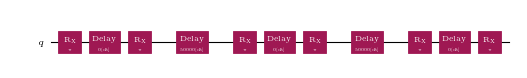

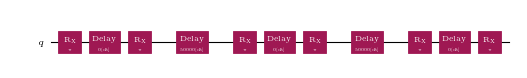

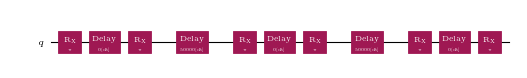

In [3]:
directory = "development/results/paper/sim_Id"
fileNames = ['Id_s1', 'Id_s2', 'Id_s8']

for i, fileName in enumerate(fileNames):
    
    # load kwargs from QPY file 
    kwargs = getKwargs(directory, fileName)
    print(kwargs)
    print('------------')
    print(kwargs['qc'].metadata)
    print('------------')

    fig, ax = plt.subplots()
    kwargs['qc'].draw('mpl', ax=ax)
    
    # load result from CSV file
    # t_list, rdo_list = getResult(directory, fileName)

## eval

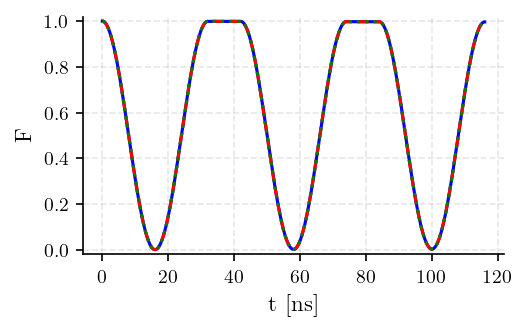

In [11]:
directory = "development/results/paper/sim_Id"
fileNames = ['Id_s8', 'Id_s2', 'Id_s1']

fig, ax = plt.subplots()

colors = ['b', 'r', 'g']
labels = [r'$s=1/8$', r'$s=1/2$', r'$s=1$']
ls = ['-','--', ':']

for i, fileName in enumerate(fileNames):
    
    kwargs = getKwargs(directory, fileName)
    t_list, rdo_list = getResult(directory, fileName)

    omegaQ = 2*np.pi*np.array(kwargs['freqQ'])
    omegaQmax = max(omegaQ)
    t = t_list / omegaQmax

    U = Operator(kwargs["qc"]).data
    target = U @ kwargs["rhoIni"] @ U.conj().T
    fids = [getFidelity(rho, target) for rho in rdo_list]

    ax.plot(t, fids, linewidth=1.5, color=colors[i], label=labels[i], ls=ls[i])
    ax.set_xlabel("t [ns]")
    ax.set_ylabel("F")
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)

development/results/paper/sim_Id
Saved quantum circuit data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development/results/paper/sim_Id\qcData_Id_s8.
{'idlingTime': np.float64(0.0), 'gateList': [[[0], 'rxyStep', {'omega': -1.0, 'gateTime': 502.6548245743669}]], 'bath': [{'type': 'broadband', 'beta': 7.998738455610368, 'kappa': 5.066059182116889e-07, 'omegaC': 20, 'exp': 0.125, 'tol': 1e-06}], 'dtFB': np.float64(0.0031415926535897937), 'stride': 1000, 'depth': [1], 'bondDim': 5, 'isRK13': False, 'useRFPlus': False, 'rho': {'numQ': 1, 'omegaQ': [1.0], 'rhoReal': [[1.0, 0.0], [0.0, 0.0]], 'rhoImag': [[0.0, 0.0], [0.0, 0.0]]}, 'VTmp': {'real': [[[0.0, 1.0], [1.0, 0.0]]], 'imag': [[[0.0, 0.0], [0.0, 0.0]]]}, 'omegaQmax': np.float64(31.41592653589793)}


C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\ttheom\bath\broadband.py:56: RuntimeWarning: overflow encountered in exp
  / (1. + (x / omegaC)**2)**2 / (1. - np.exp(-beta * x)))
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:280: RuntimeWarning: divide by zero encountered in divide
  C_pol = 1.0 / (pol[:,None] - zj[None,:])
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:280: RuntimeWarning: invalid value encountered in divide
  C_pol = 1.0 / (pol[:,None] - zj[None,:])
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:281: RuntimeWarning: invalid value encountered in dot
  N_pol = C_pol.dot(fj*wj)
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:283: RuntimeWarning: invalid value encountered in divide
  res = N_pol / Ddiff_pol
<string>:59: UserWarning: Attempting to set 

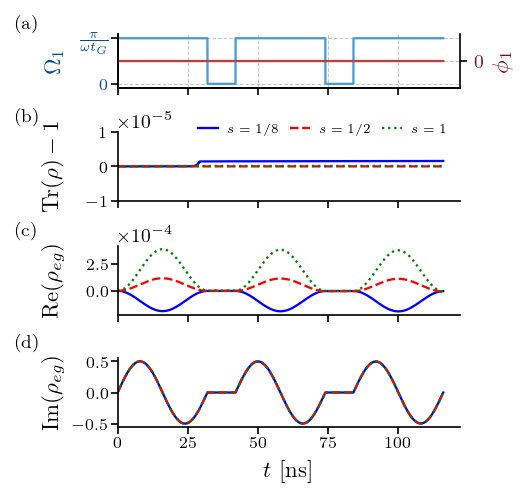

In [12]:
directory = "development/results/paper/sim_Id"
fileNames = ["Id_s8", "Id_s2", "Id_s1"]

colors = ["b", "r", "g"]
labels = [r"$s=1/8$", r"$s=1/2$", r"$s=1$"]
ls = ["-", "--", ":"]

fig, axes = plt.subplots(
    4,
    1,
    figsize=(3.4, 3.2),
    sharex=True,
    gridspec_kw={"height_ratios": [0.8, 1.0, 1.0, 1.0]},
)

# (a) pulse sequence
kwargs = getKwargs(directory, fileNames[0])
fig, ax = plotPulseSeq(fig=fig, ax=axes[0], **kwargs)
axes[0].set_xlabel("")

for i, fileName in enumerate(fileNames):
    kwargs = getKwargs(directory, fileName)
    t_list, rdo_list = getResult(directory, fileName)

    omegaQ = 2 * np.pi * np.array(kwargs["freqQ"])
    omegaQmax = max(omegaQ)
    t = t_list / omegaQmax

    trace_list = [np.trace(rho) - 1 for rho in rdo_list]
    rho_eg_real = [dm[0, 1].real for dm in rdo_list]
    rho_eg_imag = [dm[0, 1].imag for dm in rdo_list]

    axes[1].plot(t, trace_list, color=colors[i], label=labels[i], ls=ls[i], lw=1.1)
    axes[2].plot(t, rho_eg_real, color=colors[i], label=labels[i], ls=ls[i], lw=1.1)
    axes[3].plot(t, rho_eg_imag, color=colors[i], label=labels[i], ls=ls[i], lw=1.1)

axes[1].set_ylim(-1e-5, 1e-5)
axes[1].set_ylabel(r"$\mathrm{Tr}(\rho)-1$")
axes[2].set_ylabel(r"$\mathrm{Re}(\rho_{eg})$")
axes[3].set_ylabel(r"$\mathrm{Im}(\rho_{eg})$")
axes[2].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
axes[-1].set_xlabel(r"$t$ [ns]")

for ax in axes:
    ax.set_xlim(0)
    ax.tick_params(axis="both", labelsize=8, pad=1)

# panel labels
panel_labels = ["(a)", "(b)", "(c)", "(d)"]
for ax, label in zip(axes, panel_labels):
    ax.text(
        -0.3,
        1.35,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        fontweight="bold",
    )

# one shared legend
axes[1].legend(
    fontsize=6,
    ncols=3,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.6, 1.3),
    handlelength=1.6,
    columnspacing=0.9,
)

fig.align_ylabels(axes)
fig.subplots_adjust(hspace=0.25)

fig.savefig(os.path.join(directory, "Id_comparison.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(directory, "Id_comparison.svg"), bbox_inches="tight")